Create Plots to look at the jet and heat transport at different rotation rates

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

In [2]:
file_indices = [0.01,0.025,0.05,0.075,0.1,0.25,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.75,2.0]
print(file_indices)

rotation = np.round(file_indices,3)
print(rotation)

[0.01, 0.025, 0.05, 0.075, 0.1, 0.25, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.75, 2.0]
[0.01  0.025 0.05  0.075 0.1   0.25  0.5   0.6   0.7   0.8   0.9   1.
 1.1   1.2   1.3   1.4   1.5   1.75  2.   ]


In [3]:
file_template = "../rotation/{}.nc"
results = []

In [4]:
for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run = {
        "month": [],
        "tsurf_diff": [], "tsurf_diff_nhem": [], "tsurf_diff_shem": [],
        "st_diff": [], "st_diff_nhem": [], "st_diff_shem": [],
        "tsurf_equator": [], "tsurf_shem": [], "tsurf_nhem": [], "tsurf_poles": [],
        "st_equator": [], "st_shem": [], "st_nhem": [], "st_poles": [],
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run["month"].append(months)

        for month, data in monthly_data:

            # Surface temperature differences
            tsurf_diff = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(0,48))[0]
            tsurf_diff_nhem = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(0,24))[0]
            tsurf_diff_shem = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(24,48))[0]

            # Surface temperature values
            tsurf_eq = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(0,48))[1]
            tsurf_p = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(0,48))[2]
            tsurf_n = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(0,24))[2]
            tsurf_s = Tempdiff.temp_diff(data, "tsurf", lat_slice=slice(24,48))[2]

            run["tsurf_diff"].append(tsurf_diff)
            run["tsurf_diff_nhem"].append(tsurf_diff_nhem)
            run["tsurf_diff_shem"].append(tsurf_diff_shem)
            run["tsurf_equator"].append(tsurf_eq)
            run["tsurf_poles"].append(tsurf_p)
            run["tsurf_nhem"].append(tsurf_n)
            run["tsurf_shem"].append(tsurf_s)

            # Soil temperature differences
            st_diff = Tempdiff.temp_diff(data, "st", lat_slice=slice(0,48))[0]
            st_diff_nhem = Tempdiff.temp_diff(data, "st", lat_slice=slice(0,24))[0]
            st_diff_shem = Tempdiff.temp_diff(data, "st", lat_slice=slice(24,48))[0] 

            # Soil temperature values
            st_eq = Tempdiff.temp_diff(data, "st", lat_slice=slice(0,48))[1]
            st_p = Tempdiff.temp_diff(data, "st", lat_slice=slice(0,48))[2]
            st_n = Tempdiff.temp_diff(data, "st", lat_slice=slice(0,24))[2]
            st_s = Tempdiff.temp_diff(data, "st", lat_slice=slice(24,48))[2]

            run["st_diff"].append(st_diff)
            run["st_diff_nhem"].append(st_diff_nhem)
            run["st_diff_shem"].append(st_diff_shem)
            run["st_equator"].append(st_eq)
            run["st_poles"].append(st_p)
            run["st_nhem"].append(st_n)
            run["st_shem"].append(st_s) 

    # convert lists to numpy arrays (for math/plotting later)
    for k in run:
        if run[k] is None:
            continue
        if isinstance(run[k], list):
            run[k] = np.array(run[k]) 

    # Store results
    results.append({"file": fname, "data": run})


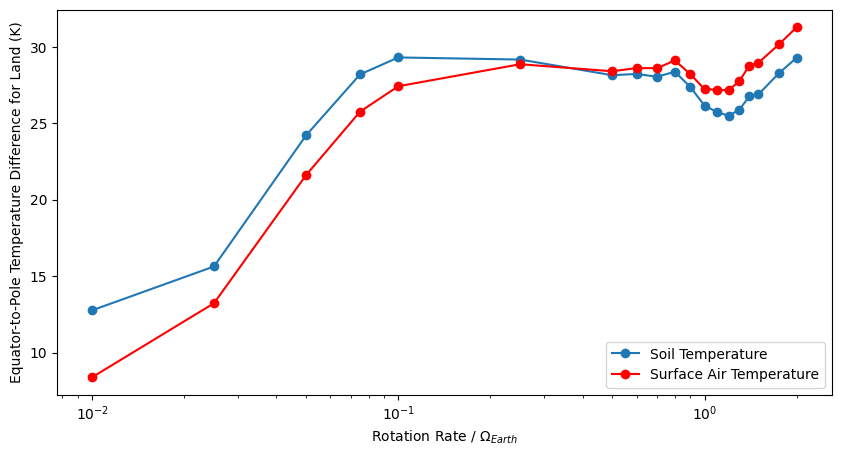

In [5]:
fig = plt.figure(figsize=(10, 5))
y_sm = []
y_st = []
y_tsurf = []
x = []
for r, rot in zip(results, rotation):
    st = r["data"]["st_diff"].mean()
    tsurf = r["data"]["tsurf_diff"].mean()
    x.append(rot)
    y_st.append(st)
    y_tsurf.append(tsurf)

plt.plot(x, y_st, marker='o', label="Soil Temperature")
plt.plot(x, y_tsurf, marker='o', label="Surface Air Temperature", color="red")
plt.xlabel("Rotation Rate / $\Omega_{Earth}$")
plt.ylabel("Equator-to-Pole Temperature Difference for Land (K)")
plt.xscale("log")
plt.legend(loc="lower right")
plt.show()

In [7]:
results_all = []

for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run_all = {
        "month": [],
        "temp_diff": [], "temp_diff_nhem": [], "temp_diff_shem": [],
        "temp_equator": [], "temp_shem": [], "temp_nhem": [], "temp_poles": [],
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run_all["month"].append(months)

        for month, data in monthly_data:

            # Surface temperature differences
            tsurf_diff = Tempdiffall.temp_diff(data, lat_slice=slice(0,48))[0]
            tsurf_diff_nhem = Tempdiffall.temp_diff(data, lat_slice=slice(0,24))[0]
            tsurf_diff_shem = Tempdiffall.temp_diff(data, lat_slice=slice(24,48))[0]

            # Surface temperature values
            tsurf_eq = Tempdiffall.temp_diff(data, lat_slice=slice(0,48))[1]
            tsurf_p = Tempdiffall.temp_diff(data, lat_slice=slice(0,48))[2]
            tsurf_n = Tempdiffall.temp_diff(data, lat_slice=slice(0,24))[2]
            tsurf_s = Tempdiffall.temp_diff(data, lat_slice=slice(24,48))[2]

            run_all["temp_diff"].append(tsurf_diff)
            run_all["temp_diff_nhem"].append(tsurf_diff_nhem)
            run_all["temp_diff_shem"].append(tsurf_diff_shem)
            run_all["temp_equator"].append(tsurf_eq)
            run_all["temp_poles"].append(tsurf_p)
            run_all["temp_nhem"].append(tsurf_n)
            run_all["temp_shem"].append(tsurf_s)

    # convert lists to numpy arrays (for math/plotting later)
    for k in run_all:
        if run_all[k] is None:
            continue
        if isinstance(run_all[k], list):
            run_all[k] = np.array(run_all[k]) 

    # Store results
    results_all.append({"file": fname, "data": run_all})

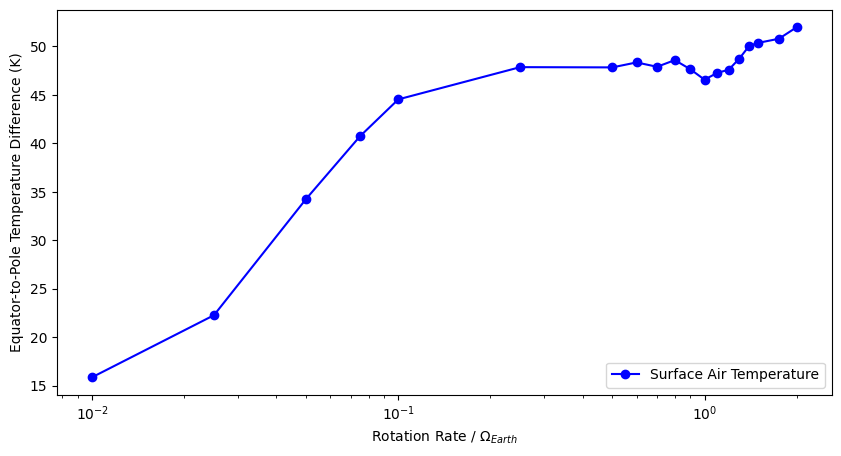

In [10]:
fig = plt.figure(figsize=(10, 5))
y_all = []
x_all = []
for r, rot in zip(results_all, rotation):
    tsurf = r["data"]["temp_diff"].mean()
    x_all.append(rot)
    y_all.append(tsurf)

plt.plot(x_all, y_all, marker='o', label="Surface Air Temperature", color="blue")
plt.xlabel("Rotation Rate / $\Omega_{Earth}$")
plt.ylabel("Equator-to-Pole Temperature Difference (K)")
plt.xscale("log")
plt.legend(loc="lower right")
plt.show()